In [1]:
import numpy as np

import scarf

scarf.configure_output(level="WARNING", progress=False)

dataset = scarf.cytebase.connect("scarf_docs").download_dataset(
    "tenx_5K_pbmc_rnaseq", destination="scarf_datasets", zarr=True
)
ds = scarf.DataStore(f"{dataset}/data.zarr", nthreads=4)
run = ds.pipeline.open(label="docs_default")
graph_ref = run["connectivity_map"]
ds

Downloading bucket files: 56215324 / 56215324 complete

Downloading bytes: 56215324 / 56215324 complete

DataStore has 3948 (5025) cells with 1 assays: RNA
   Cell metadata:
            'I', 'ids', 'names', 'RNA_G2M_score', 'RNA_S_score', 
            'RNA_UMAP1', 'RNA_UMAP2', 'RNA_cell_cycle_phase', 'RNA_clusters', 'RNA_doublet_score', 
            'RNA_leiden_cluster', 'RNA_nCounts', 'RNA_nFeatures', 'RNA_paris_cluster', 'RNA_percentMito', 
            'RNA_percentRibo'
   RNA assay has 33538 features and following metadata:
            'I', 'ids', 'names', 'dropOuts', 'feature_type', 
            'genome', 'nCells'

In [2]:
graph = ds.load_graph(graph=graph_ref, symmetric=True, upper_only=False)
graph_strength = np.asarray(graph.sum(axis=1)).ravel()
ds.cells.insert(
    column_name="customGraphStrength", values=graph_strength, key="I", overwrite=True
)
{
    "cells": int(graph.shape[0]),
    "edges": int(graph.nnz),
    "customGraphStrength mean": float(graph_strength.mean()),
}

{'cells': 3948, 'edges': 64990, 'customGraphStrength mean': 10.058904647827148}

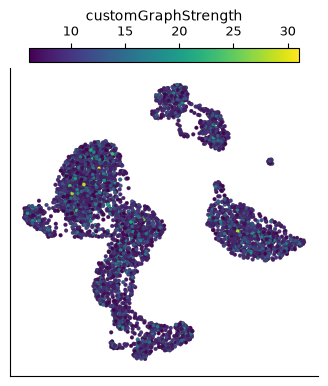

In [3]:
ds.plots.embedding(layout=run["umap"], color_by="customGraphStrength")

In [4]:
cell_index = np.flatnonzero(run.cells.fetch_all("I"))
hvg_values = np.asarray(run.features.fetch_all("highly_variable_features"), dtype=bool)
feature_index = np.flatnonzero(hvg_values)
selected_counts = ds.RNA.rawData[:, feature_index][cell_index, :]

{"selected cells": len(cell_index), "selected genes": len(feature_index)}

{'selected cells': 3948, 'selected genes': 500}

In [5]:
detected_blocks = []
for count_block in selected_counts.stream_blocks(
    nthreads=4, msg="Calculating custom detection statistic"
):
    detected_blocks.append(np.count_nonzero(count_block, axis=1))
sum(len(block) for block in detected_blocks)

3948

In [6]:
detected_hvgs = np.concatenate(detected_blocks)
ds.cells.insert(
    column_name="customDetectedHVGs", values=detected_hvgs, key="I", overwrite=True
)
{
    "cells": int(detected_hvgs.size),
    "customDetectedHVGs mean": float(detected_hvgs.mean()),
    "customDetectedHVGs max": int(detected_hvgs.max()),
}

{'cells': 3948,
 'customDetectedHVGs mean': 123.48024316109422,
 'customDetectedHVGs max': 250}

In [7]:
well_connected = graph_strength >= np.quantile(graph_strength, 0.25)
ds.cells.insert(
    column_name="wellConnected",
    values=well_connected,
    fill_value=False,
    key="I",
    overwrite=True,
)
{"selected cells": int(well_connected.sum()), "active cells": len(well_connected)}

{'selected cells': 2961, 'active cells': 3948}

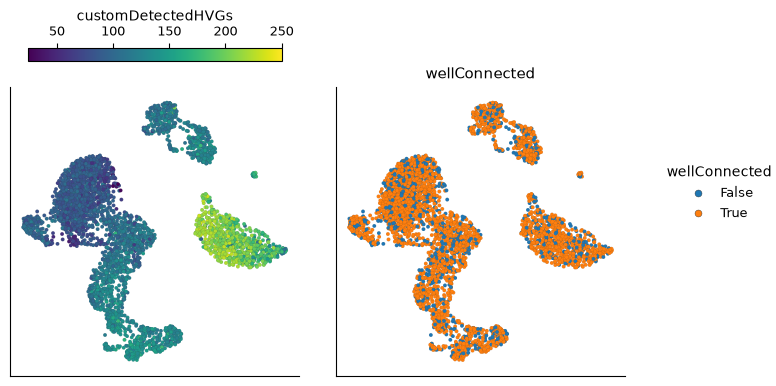

In [8]:
ds.plots.embedding(
    layout=run["umap"], color_by=["customDetectedHVGs", "wellConnected"], n_columns=2
)

In [9]:
panel_genes = ["CD3D", "MS4A1", "CD14", "LYZ", "NKG7", "GNLY"]
adata = ds.to_anndata(cell_key="wellConnected", feature_names=panel_genes)
adata.shape, adata.var_names.tolist()

((2961, 6),
 ['ENSG00000167286',
  'ENSG00000156738',
  'ENSG00000170458',
  'ENSG00000090382',
  'ENSG00000105374',
  'ENSG00000115523'])

In [10]:
from pathlib import Path
from tempfile import TemporaryDirectory

export_directory = TemporaryDirectory()
subset_path = Path(export_directory.name) / "well_connected.zarr"
writer = scarf.SubsetZarr(
    zarr_loc=str(subset_path),
    assays=[ds.RNA],
    cell_key="wellConnected",
    reset_cell_filter=False,
    overwrite_existing_file=True,
)
writer.dump()

subset = scarf.DataStore(str(subset_path))
{"exported cells": subset.cells.N, "retained genes": subset.RNA.feats.N}

{'exported cells': 2961, 'retained genes': 33538}